### Подготовка библиотек

In [1]:
from common import *

Загрузка сплитов и создание загрузчиков данных

In [ ]:
with open("outputs/splits_info.json", "r") as f: # открываем файл с информацией о сплитах
    cfg = json.load(f) # загружаем информацию о сплитах

CLASS_NAMES = cfg["class_names"] # список классов
BATCH_SIZE = cfg["batch_size"] # размер батча
IMG_SIZE = cfg["img_size"] # размер изображения
SEED = cfg["seed"] # seed для повторяемости
train_indices = cfg["train_indices"] # индексы обучающего набора
val_indices = cfg["val_indices"] # индексы валидационного набора

train_dataset = BloodCellsDataset(TRAIN_DIR, transform=train_transform) # создаем обучающий набор
val_dataset = BloodCellsDataset(TRAIN_DIR, transform=val_test_transform) # создаем валидационный набор
test_dataset = BloodCellsDataset(TEST_DIR, transform=val_test_transform) # создаем тестовый набор

train_dataset.samples = [train_dataset.samples[i] for i in train_indices] # изменяем образцы обучающего набора
val_dataset.samples = [val_dataset.samples[i] for i in val_indices] # изменяем образцы валидационного набора

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True) # создаем загрузчик для обучающего набора
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) # создаем загрузчик для валидационного набора
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) # создаем загрузчик для тестового набора

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 7965, Val: 1992, Test: 2487


### Создание baseline моделей и их оценка

ResNet18

Epoch 1/10 - Train Loss: 0.6390, Train Acc: 0.7248 - Val Loss: 0.8192, Val Acc: 0.7385, Val Bal Acc: 0.7392, Val F1: 0.7255
Epoch 2/10 - Train Loss: 0.3086, Train Acc: 0.8830 - Val Loss: 0.5429, Val Acc: 0.8203, Val Bal Acc: 0.8201, Val F1: 0.8238
Epoch 3/10 - Train Loss: 0.2010, Train Acc: 0.9219 - Val Loss: 0.4523, Val Acc: 0.8338, Val Bal Acc: 0.8339, Val F1: 0.8351
Epoch 4/10 - Train Loss: 0.1653, Train Acc: 0.9368 - Val Loss: 0.2526, Val Acc: 0.9011, Val Bal Acc: 0.9013, Val F1: 0.9002
Epoch 5/10 - Train Loss: 0.1599, Train Acc: 0.9379 - Val Loss: 0.2362, Val Acc: 0.8996, Val Bal Acc: 0.8999, Val F1: 0.8956
Epoch 6/10 - Train Loss: 0.0712, Train Acc: 0.9751 - Val Loss: 0.0527, Val Acc: 0.9819, Val Bal Acc: 0.9820, Val F1: 0.9820
Epoch 7/10 - Train Loss: 0.0502, Train Acc: 0.9843 - Val Loss: 0.0468, Val Acc: 0.9809, Val Bal Acc: 0.9810, Val F1: 0.9810
Epoch 8/10 - Train Loss: 0.0471, Train Acc: 0.9854 - Val Loss: 0.0441, Val Acc: 0.9794, Val Bal Acc: 0.9795, Val F1: 0.9795
Epoch 9/

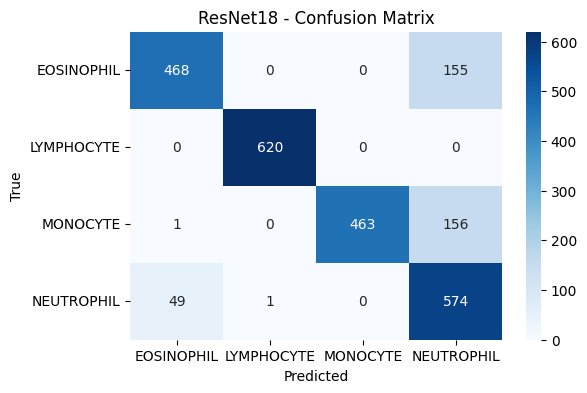

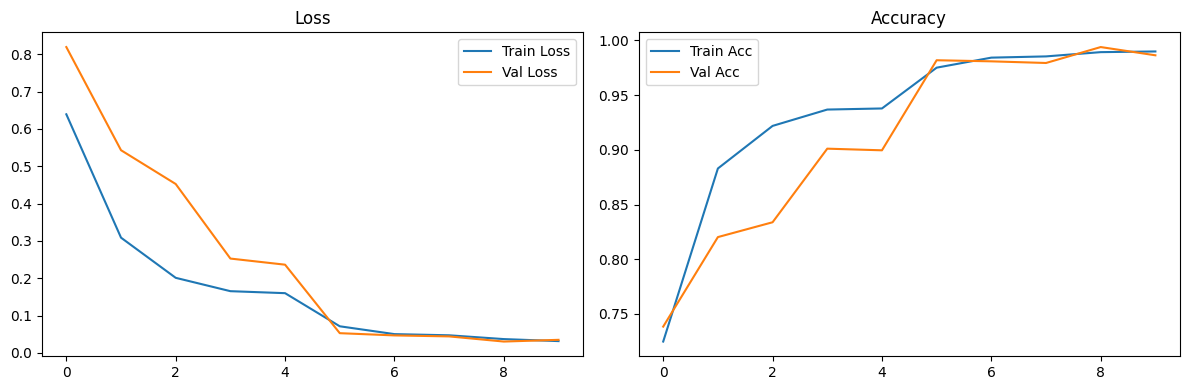


ResNet18 - Classification report:
              precision    recall  f1-score   support

  EOSINOPHIL       0.90      0.75      0.82       623
  LYMPHOCYTE       1.00      1.00      1.00       620
    MONOCYTE       1.00      0.75      0.86       620
  NEUTROPHIL       0.65      0.92      0.76       624

    accuracy                           0.85      2487
   macro avg       0.89      0.85      0.86      2487
weighted avg       0.89      0.85      0.86      2487

Модель сохранена в outputs/resnet18_baseline.pth


In [ ]:
resnet18 = models.resnet18(weights=None) # создаем модель ResNet18
resnet18.fc = nn.Linear(resnet18.fc.in_features, len(CLASS_NAMES)) # изменяем последний слой на линейный слой с числом выходов равным числу классов

# обучение модели
resnet18_model, resnet18_result = train_model( 
    resnet18, # модель
    "ResNet18", # название модели
    train_loader, # загрузчик для обучающего набора
    val_loader, # загрузчик для валидационного набора
    test_loader, # загрузчик для тестового набора
    epochs=10, # количество эпох
    lr=1e-3, # learning rate
)

torch.save(resnet18_model.state_dict(), "outputs/resnet18_baseline.pth") # сохраняем модель
print("Модель сохранена в outputs/resnet18_baseline.pth")

ResNet18 (baseline): Модель ResNet18, обученная с нуля (без предобучения), за 10 эпох достигла Test Accuracy 0.8544, Balanced Accuracy 0.8545, Macro-F1 0.8588. 

Обучение прошло стабильно: функция потерь монотонно убывала (с 0.639 до 0.031), валидационная точность достигла ~98.6% к последней эпохе. Наибольшая ошибка в Confusion Matrix — между классами Monocyte и Eosinophil, что объясняется схожестью морфологических признаков этих клеток. Метрики на тесте ожидаемо ниже валидационных, поскольку тестовая выборка снималась в других условиях.

Swin-T

Epoch 1/10 - Train Loss: 0.4782, Train Acc: 0.8030 - Val Loss: 0.0839, Val Acc: 0.9654, Val Bal Acc: 0.9655, Val F1: 0.9654
Epoch 2/10 - Train Loss: 0.1046, Train Acc: 0.9631 - Val Loss: 0.0629, Val Acc: 0.9744, Val Bal Acc: 0.9745, Val F1: 0.9744
Epoch 3/10 - Train Loss: 0.0498, Train Acc: 0.9844 - Val Loss: 0.0233, Val Acc: 0.9905, Val Bal Acc: 0.9905, Val F1: 0.9905
Epoch 4/10 - Train Loss: 0.0305, Train Acc: 0.9916 - Val Loss: 0.0139, Val Acc: 0.9950, Val Bal Acc: 0.9950, Val F1: 0.9950
Epoch 5/10 - Train Loss: 0.0284, Train Acc: 0.9920 - Val Loss: 0.0073, Val Acc: 0.9970, Val Bal Acc: 0.9970, Val F1: 0.9970
Epoch 6/10 - Train Loss: 0.0140, Train Acc: 0.9969 - Val Loss: 0.0048, Val Acc: 0.9985, Val Bal Acc: 0.9985, Val F1: 0.9985
Epoch 7/10 - Train Loss: 0.0142, Train Acc: 0.9975 - Val Loss: 0.0047, Val Acc: 0.9985, Val Bal Acc: 0.9985, Val F1: 0.9985
Epoch 8/10 - Train Loss: 0.0111, Train Acc: 0.9984 - Val Loss: 0.0041, Val Acc: 0.9985, Val Bal Acc: 0.9985, Val F1: 0.9985
Epoch 9/

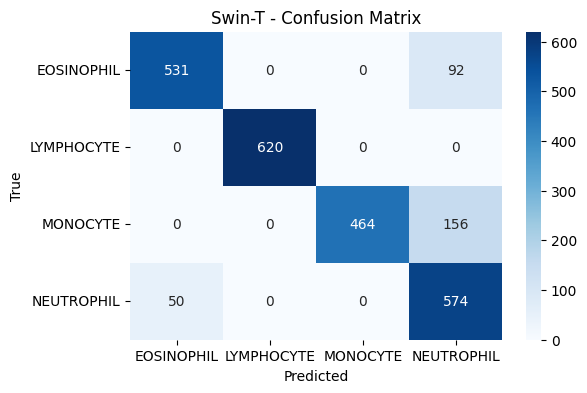

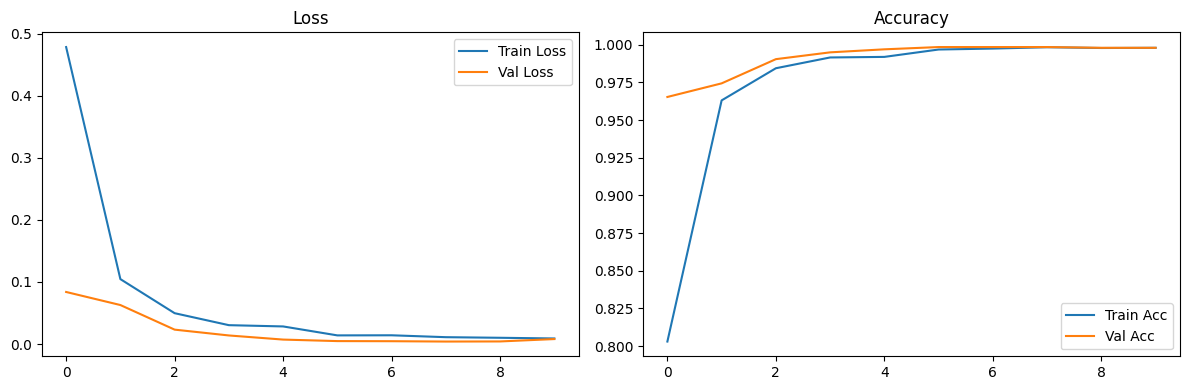


Swin-T - Classification report:
              precision    recall  f1-score   support

  EOSINOPHIL       0.91      0.85      0.88       623
  LYMPHOCYTE       1.00      1.00      1.00       620
    MONOCYTE       1.00      0.75      0.86       620
  NEUTROPHIL       0.70      0.92      0.79       624

    accuracy                           0.88      2487
   macro avg       0.90      0.88      0.88      2487
weighted avg       0.90      0.88      0.88      2487

Модель сохранена в outputs/swin_baseline.pth


In [ ]:
swin = models.swin_t(weights=models.Swin_T_Weights.IMAGENET1K_V1) # создаем модель Swin-T
swin.head = nn.Linear(swin.head.in_features, len(CLASS_NAMES)) # изменяем последний слой на линейный слой с числом выходов равным числу классов

# обучение модели
swin_model, swin_result = train_model(
    swin, # модель
    "Swin-T", # название модели
    train_loader, # загрузчик для обучающего набора
    val_loader, # загрузчик для валидационного набора
    test_loader, # загрузчик для тестового набора
    epochs=10, # количество эпох
    lr=2e-5,
)

torch.save(swin_model.state_dict(), "outputs/swin_baseline.pth") # сохраняем модель
print("Модель сохранена в outputs/swin_baseline.pth")

Swin-T (baseline): Модель Swin-T с предобученными весами ImageNet-1K за 10 эпох достигла Test Accuracy 0.8802, Balanced Accuracy 0.8801, Macro-F1 0.8830 — устойчиво превзошла ResNet18. 

Кривая обучения более гладкая: функция потерь упала с 0.478 до 0.009. 
Преимущество Swin-T объясняется: 
1) иерархическим window attention, хорошо захватывающим как локальные, так и глобальные признаки клеток; 
2) предобученными весами, которые уже кодируют визуальные паттерны, применимые к гистологическим изображениям.

Сравнительная таблица

In [5]:
baseline_results = [resnet18_result, swin_result]
df_baseline = pd.DataFrame(baseline_results)

print("\nСравнительная таблица baseline моделей:")
display(df_baseline[["model", "test_acc", "test_bal_acc", "test_f1_macro"]])

df_baseline.to_csv("outputs/baseline_results.csv", index=False)
print("Результаты сохранены в outputs/baseline_results.csv")


Сравнительная таблица baseline моделей:


,model,test_acc,test_bal_acc,test_f1_macro
0,ResNet18,0.854443,0.854462,0.858832
1,Swin-T,0.880177,0.880147,0.883016


Результаты сохранены в outputs/baseline_results.csv


Сохранение результатов моделей

In [6]:
all_results = load_results()
all_results["baseline_resnet18"] = resnet18_result
all_results["baseline_swin"] = swin_result

save_results(all_results)

Результаты сохранены в outputs/experiment_results.pkl


Swin-T показале себя лучше ResNet18. Обе модели показывают значительный разрыв между валидационной (~99%) и тестовой (~85–88%) точностью, что указывает на распределительный сдвиг между train/val и test выборками.

Гипотезы для проверки:
1. Аугментация данных улучшает качество модели.
2. Замена модели StepLR на CosineAnnealingLR улучшит качество модели. (плавное уменьшение LR по косинусу)
3. Раздельный learning rate для backbone и head улучшит качество модели. (меньший LR для backbone, больший для head)
4. Увеличение количества эпох обучения улучшит качество модели.
5. Заморозка backbone и обучение только head с weight_decay улучшит качество модели.
6. Комбинация: аугментация + больше эпох + CosineAnnealingLR + label smoothing улучшит качество модели ResNet18. Для Swin-T проверим аугментацию + больше эпох + CosineAnnealingLR + label smoothing + AdamW + weight_decay.